<h1 align="center">PROIECT MACHINE LEARNING</h1>

<h3 align="center">ANALIZA	COMPARATA	A	MODELELOR	DE	MACHINE	LEARNING, IN CLASIFICARE</h3>

<h3 allign="left">4.1.	Definirea	problemei</h3>

<h4 allign="left">4.1.1.	Problem abordata</h4>

Problema abordata in acest proiect consta in analiza factorilor socio-demografici care influenteaza statutul economic al persoanelor, utilizand setul de date "Adult Income". Prin intermediul metodelor de Machine Learning, se urmareste extragerea unor tipare pentru a automatiza predictia profilului financiar.

<h4 allign="left">4.1.2. Obiectivele cercetarii</h4>

Proiectul este impartit in doua directii de analiza:

1. Sarcina de Clasificare (Predictia Nivelului de Venit):

* Clasele existente:
    * (<=50K) (Venit scazut/mediu): Persoane cu un venit anual mai mic sau egal cu 50.000$.

    * (>50K) (Venit ridicat): Persoane cu un venit anual care depaseste 50.000$.

* Semnificatie: Identificarea automata a persoanelor cu potential economic ridicat.

2. Sarcina de Regresie (Predictia Timpului de Lucru):

* Variabila de iesire: hours-per-week.

* Semnificatie practica: Estimarea numarului de ore pe care o persoana le dedica muncii saptamanal.

* Unitate de masura: Ore / saptamana.

* Interval de valori: Aproximativ intre 1 si 99 de ore.

<h4 allign="left">4.1.3. Identificarea Variabilelor (Features)</h4>

Variabilele de intrare utilizate pentru ambele modele includ:

* Caracteristici Numerice: Varsta (age), nivelul de educatie exprimat numeric (educational-num), castigurile si pierderile de capital (capital-gain, capital-loss).

* Caracteristici Categorice: Nivelul de instruire (education), starea civila (marital-status), ocupatia (occupation), relatia familiala (relationship), rasa (race), genul (gender) si tara de origine (native-country).

<h4 allign="left">4.1.4. Relevanta practica si utilitatea modelelor</h4>

Construirea acestor modele de Machine Learning este utila din mai multe perspective:

* Socio-economic: Ajuta la intelegerea disparitatilor salariale si a modului in care educatia sau mediul social influenteaza succesul financiar.

* Marketing si Finante: Institutiile bancare pot utiliza modelul de clasificare pentru a evalua bonitatea unui client, iar companiile de marketing pot segmenta audienta in functie de puterea de cumparare estimata.

* Resurse Umane: Modelul de regresie poate oferi perspective asupra echilibrului dintre viata profesionala si cea privata (work-life balance) in diferite sectoare ocupationale.

<h4 allign="left">4.1.5. Motivatia alegerii problemei</h4>

Am ales aceasta problema deoarece ofera un set de date echilibrat intre variabile numerice si categorice, reprezentand o provocare interesanta pentru preprocesarea datelor (Encoding, Scaling). De asemenea, impactul social al predictiei venitului este un subiect actual, oferind posibilitatea de a analiza modul in care caracteristicile personale se reflecta in rezultate economice concrete intr-o societate moderna.

<h3 allign="center">4.2.	Analiza	exploratorie	a	datelor	si	pregatirea	lor</h3>

<h4 allign="left">4.2.1. Importul librariilor si incarcarea datelor</h4>

in acest pas, am incarcat setul de date si am identificat faptul ca valorile lipsa sunt reprezentate prin caracterul ?. Prin parametrul na_values, am transformat aceste instante in NaN pentru a putea fi gestionate corect.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

df = pd.read_csv('data/adult.csv', na_values='?')

df.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K


<h4 allign="left">4.2.2. Explorarea structurii si calitatii datelor</h4>

Setul de date contine atat variabile numerice (ex: age, hours-per-week), cat si categorice (ex: workclass, education). Am identificat valori lipsa in coloanele workclass, occupation si native-country. Avand in vedere volumul mare de date, vom decide strategia de imputare sau eliminare in pasul urmator.

In [2]:

print(df.info())


missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])

<class 'pandas.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   age              48842 non-null  int64
 1   workclass        46043 non-null  str  
 2   fnlwgt           48842 non-null  int64
 3   education        48842 non-null  str  
 4   educational-num  48842 non-null  int64
 5   marital-status   48842 non-null  str  
 6   occupation       46033 non-null  str  
 7   relationship     48842 non-null  str  
 8   race             48842 non-null  str  
 9   gender           48842 non-null  str  
 10  capital-gain     48842 non-null  int64
 11  capital-loss     48842 non-null  int64
 12  hours-per-week   48842 non-null  int64
 13  native-country   47985 non-null  str  
 14  income           48842 non-null  str  
dtypes: int64(6), str(9)
memory usage: 9.3 MB
None
workclass         2799
occupation        2809
native-country     857
dtype: int64


<h4 allign="left">4.2.3. Gestionarea valorilor lipsa si a anomaliilor</h4>

Am ales sa imputam valorile lipsa folosind valoarea cea mai frecventa, deoarece toate coloanele cu date lipsa sunt categorice. Am eliminat duplicatele pentru a evita overfitting. Boxplot-ul pentru varsta indica prezenta unor valori extreme peste 80 de ani, dar acestea sunt plauzibile biologic, deci le vom pastra pentru a nu pierde diversitatea populatiei.

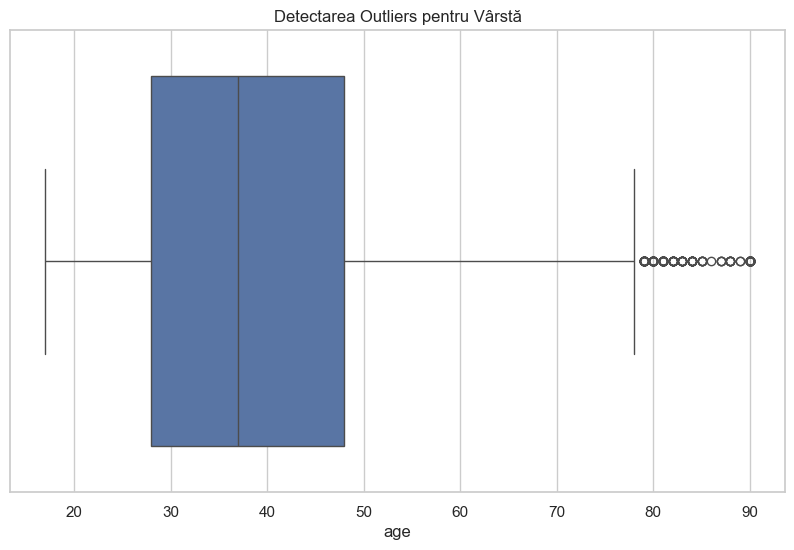

In [3]:

for col in ['workclass', 'occupation', 'native-country']:
    df[col] = df[col].fillna(df[col].mode()[0])

df = df.drop_duplicates()

sns.boxplot(x=df['age'])
plt.title('Detectarea Outliers pentru Varsta')
plt.show()

<h4 allign="left">4.2.4. Analiza grafica si a relatiilor dintre variabile</h4>


<h5 allign="left">A. Distributia variabilei tinta (Clasificare)</h5>

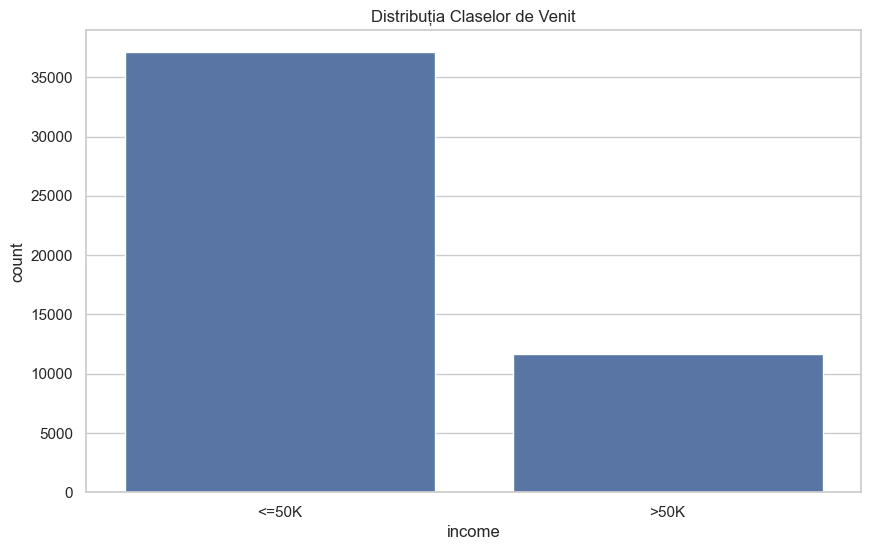

In [4]:
sns.countplot(data=df, x='income')
plt.title('Distributia Claselor de Venit')
plt.show()

Observam un class imbalance: aproximativ 75% din populatie castiga $\le 50K$, in timp ce doar 25% depasesc acest prag. Acest lucru ne indica faptul ca acuratetea nu va fi o metrica suficienta, fiind necesara analiza F1-Score.

<h5 allign="left">B. Impactul educatiei asupra venitului</h5>

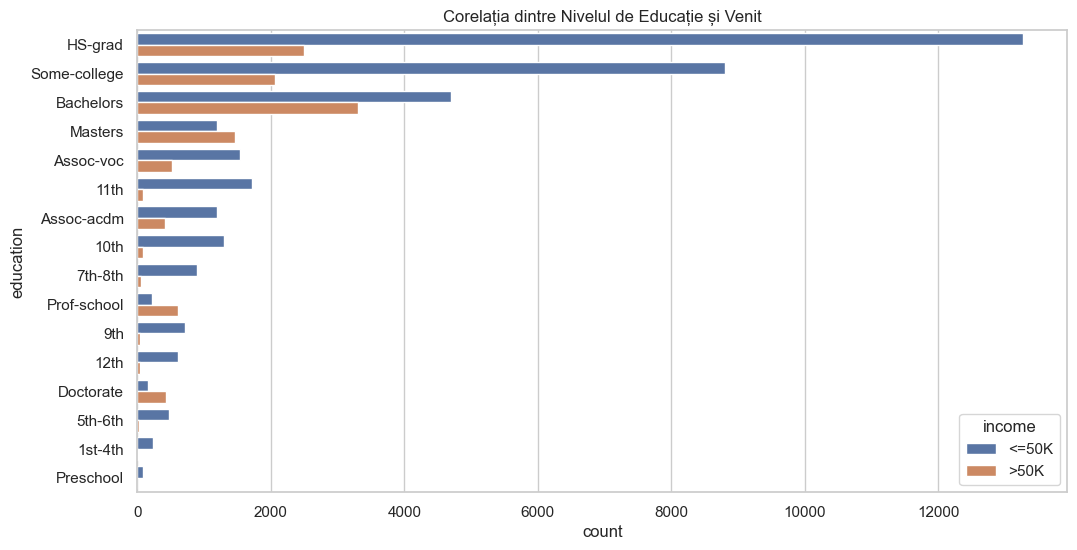

In [5]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, y='education', hue='income', order=df['education'].value_counts().index)
plt.title('Corelatia dintre Nivelul de Educatie si Venit')
plt.show()

Graficul releva o corelatie puternica intre studiile superioare si venit. Persoanele cu titluri de "Bachelors", "Masters" sau "Prof-school" au o proportie mult mai mare de reprezentare in categoria $>50K$ comparativ cu cei care au absolvit doar liceul (HS-grad).

<h4 allign="left">4.2.5. Pregatirea datelor pentru modelele ML</h4>

Transformam datele in format numeric.

In [6]:
from sklearn.preprocessing import LabelEncoder

df = df.drop('fnlwgt', axis=1)

df['income'] = df['income'].map({'<=50K': 0, '>50K': 1})

df_final = pd.get_dummies(df, drop_first=True)

print(f"Numar total de coloane dupa One-Hot Encoding: {df_final.shape[1]}")

Număr total de coloane după One-Hot Encoding: 97


Pentru a pregati datele pentru algoritmi:

1. Am eliminat fnlwgt deoarece este o variabila de esantionare administrativa.

2. Am mapat variabila tinta income in valori binare (0 si 1).

3. Am aplicat One-Hot Encoding pentru restul variabilelor categorice, transformandu-le in coloane numerice pe care modelele precum Random Forest sau Logistic Regression le pot procesa.

<h3 allign="left">4.3. Antrenarea si compararea modelelor de baza</h3>

<h4 allign="left">4.3.1. Pregatirea Datelor (Train-Test Split)</h4>

Vom imparti setul de date preprocesat in 75% antrenare si 25% testare, conform cerintelor.

In [7]:
from sklearn.model_selection import train_test_split

X = df_final.drop('income', axis=1)
y = df_final['income']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

print(f"Esantion antrenare: {X_train.shape[0]} observatii")
print(f"Esantion testare: {X_test.shape[0]} observatii")

Eșantion antrenare: 36591 observații
Eșantion testare: 12198 observații


Am utilizat functia train_test_split pentru a crea subseturile de date. Am fixat random_state=42 pentru a asigura reproductibilitatea rezultatelor la fiecare rulare a notebook-ului.

<h4 allign="left">4.3.2. Antrenarea modelelor si calcularea metricilor</h4>

Vom defini o functie care sa antreneze modelele de baza si sa colecteze rezultatele.

1. Definirea functiei de evaluare

in loc sa repetam codul pentru metrici, definim o functie o singura data.

In [8]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def evalueaza_model(nume, model, X_test, y_test):
    X_test_input = X_test.values if hasattr(X_test, 'columns') else X_test

    y_pred = model.predict(X_test_input)
    y_proba = model.predict_proba(X_test_input)[:, 1] if hasattr(model, "predict_proba") else None

    return {
        "Model": nume,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba) if y_proba is not None else 0
    }

toate_rezultatele = []

2. Standardizarea Datelor (Scaling)

Deoarece algoritmii de Machine Learning pot fi sensibili la diferentele de scara intre variabile (de exemplu, varsta variaza intre 17-90, in timp ce capitalul poate fi de ordinul zecilor de mii), am aplicat tehnica de Standardizare.

In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [10]:
X_train_final = X_train_scaled
X_test_final = X_test_scaled

3. Modelele Rapide (Ruleaza in sub 10 secunde)

Algoritmii care nu consuma resurse mari.

In [11]:
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

nb = GaussianNB().fit(X_train_final, y_train)
toate_rezultatele = []
toate_rezultatele.append(evalueaza_model("Naïve Bayes", nb, X_test_final, y_test))

lr = LogisticRegression(max_iter=1000).fit(X_train_final, y_train)
toate_rezultatele.append(evalueaza_model("Logistic Regression", lr, X_test_final, y_test))

lr = LogisticRegression(max_iter=5000, solver='saga', tol=1e-3).fit(X_train_final, y_train)
toate_rezultatele.append(evalueaza_model("Logistic Regression", lr, X_test_final, y_test))
print("Logistic Regression a terminat fara erori!")

dt = DecisionTreeClassifier().fit(X_train_final, y_train)
toate_rezultatele.append(evalueaza_model("Decision Tree", dt, X_test_final, y_test))

print("Modelele rapide au fost antrenate!")

Logistic Regression a terminat fără erori!
Modelele rapide au fost antrenate!


4. Modelele Complexe (Ensemble & Boosting)

Aceste modele sunt extrem de puternice.

In [12]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from interpret.glassbox import ExplainableBoostingClassifier

pd.util = pd._testing

print("incepe antrenarea modelelor complexe...")

rf = RandomForestClassifier(n_estimators=100, random_state=42).fit(X_train_final, y_train)
toate_rezultatele.append(evalueaza_model("Random Forest", rf, X_test_final, y_test))
print("- Random Forest gata.")

xgb = XGBClassifier(n_estimators=100, random_state=42, use_label_encoder=False, eval_metric='logloss').fit(X_train_final, y_train)
toate_rezultatele.append(evalueaza_model("XGBoost", xgb, X_test_final, y_test))
print("- XGBoost gata.")

cat = CatBoostClassifier(iterations=500, verbose=0, random_state=42).fit(X_train_final, y_train)
toate_rezultatele.append(evalueaza_model("CatBoost", cat, X_test_final, y_test))
print("- CatBoost gata.")


ebm = ExplainableBoostingClassifier(random_state=42).fit(X_train_final, y_train)
toate_rezultatele.append(evalueaza_model("EBM", ebm, X_test_final, y_test))
print("- EBM gata.")

print("--- Toate modelele din Celula 3 au terminat! ---")

Începe antrenarea modelelor complexe...
- Random Forest gata.


D:\FACULTATE\SEM II\SI\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [20:07:05] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


- XGBoost gata.
- CatBoost gata.
- EBM gata.
--- Toate modelele din Celula 3 au terminat! ---


5. Modele bazate pe instante si distante (SVM & KNN)

Vom pune aici algoritmii care se bazeaza pe distante matematice. Deoarece datele sunt acum scalate (X_train_final), acestia vor rula mult mai repede.

In [13]:
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

print("incepe antrenarea modelelor bazate pe distanta...")

knn = KNeighborsClassifier(n_neighbors=5).fit(X_train_final, y_train)
toate_rezultatele.append(evalueaza_model("K-Nearest Neighbors", knn, X_test_final, y_test))
print("- KNN gata.")


svm = SVC(probability=True, max_iter=2000, random_state=42).fit(X_train_final, y_train)
toate_rezultatele.append(evalueaza_model("SVM", svm, X_test_final, y_test))
print("- SVM gata.")

print("--- Toate modelele din Celula 4 au terminat! ---")

Începe antrenarea modelelor bazate pe distanță...
- KNN gata.


D:\FACULTATE\SEM II\SI\.venv\Lib\site-packages\sklearn\svm\_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


- SVM gata.
--- Toate modelele din Celula 4 au terminat! ---


6. Rezumatul si Tabelul Comparativ


In [14]:
import pandas as pd

df_comparativ = pd.DataFrame(toate_rezultatele)

df_comparativ = df_comparativ.sort_values(by="F1-Score", ascending=False).reset_index(drop=True)

print("Clasamentul final al modelelor (dupa F1-Score):")
display(df_comparativ)


Clasamentul final al modelelor (după F1-Score):


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,XGBoost,0.871372,0.795650,0.644186,0.711952,0.927809
1,EBM,0.869897,0.791957,0.641196,0.708647,0.928265
2,CatBoost,0.869569,0.794032,0.636545,0.706620,0.928383
3,Random Forest,0.844237,0.712481,0.618272,0.662042,0.887726
4,Logistic Regression,0.847516,0.744058,0.582392,0.653373,0.905266
5,Logistic Regression,0.847762,0.745633,0.581395,0.653351,0.905353
6,Decision Tree,0.816445,0.635787,0.599668,0.617200,0.768296
7,K-Nearest Neighbors,0.820954,0.663370,0.557143,0.605634,0.839291
8,SVM,0.614691,0.367180,0.776080,0.498506,0.749492
9,Naïve Bayes,0.508854,0.330181,0.962791,0.491728,0.721314


6.1. Analiza Performantei (Top 5)
Cel mai bun rezultat: XGBoost (F1-Score: 0.711). Are cel mai bun echilibru intre Precizie si Recall.

* Al doilea cel mai bun: EBM (F1-Score: 0.708). Model de tip "glassbox" (interpretabil).

* Consistenta: CatBoost (F1-Score: 0.706). Se afla la o distanta mica de primele doua.

* Modelele clasice: Random Forest si Logistic Regression completeaza Top 5-ul cu scoruri F1 in jur de 0.65-0.66.

6.2. Observatii

* Recall vs. Precision: Observam ca la toate modelele de top, Precision (~0.79) este mai mare decat Recall (~0.64).

* Asta inseamna ca modelele sunt foarte precaute: cand prezic ca cineva castiga peste 50K, de cele mai multe ori este corect. Totusi, nu reusesc sa identifice cam 35% din persoanele care au venituri mari.

Naïve Bayes si SVM:

* Naïve Bayes are un Recall imens (0.96), dar o Precizie foarte mica (0.33). Asta inseamna ca da foarte multe alarme false.

* SVM a obtinut rezultate modeste (F1: 0.49), probabil din cauza limitarii de iteratii (max_iter=2000).

6.3. Concluzia sectiunii

Concluzii Comparare Modele:
* in urma antrenarii a 9 algoritmi diferiti, am identificat XGBoost, EBM si CatBoost ca fiind cele mai performante modele, toate depasind pragul de 0.70 pentru scorul F1.

* Desi XGBoost ofera cea mai mare acuratete generala (87.1%), selectam XGBoost si EBM pentru etapa de optimizare si interpretare. Alegem modelului EBM deoarece performanta sa ridicata si de capacitatea de a explica deciziile.

* Modelele liniare si cele bazate pe distante (SVM, KNN) au performat vizibil mai slab, sugerand existenta unor relatii non-liniare complexe in date care pot fi capturate doar de ansamblurile de arbori de decizie.

<h3 allign="center">4.4. Ajustarea	hiperparametrilor</h3>

<h4 allign="left">4.4.1. Configurarea procesului de Tuning</h4>

Vom folosi StratifiedKFold pentru a ne asigura ca distributia claselor este mentinuta in timpul cross validation.

In [15]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, StratifiedKFold


cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
rezultate_tuned = []

<h4 allign="left">4.4.2. Optimizarea celor 5 modele</h4>

<h5 allign="left">A. XGBoost (RandomizedSearchCV)</h5>

Pentru XGBoost, spatiul de cautare este mare, deci cautarea aleatorie este mai eficienta.

In [16]:
param_xgb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0]
}

grid_xgb = RandomizedSearchCV(XGBClassifier(eval_metric='logloss'), param_xgb,
                               n_iter=10, cv=cv, scoring='f1', n_jobs=-1, random_state=42)
grid_xgb.fit(X_train_final, y_train)
rezultate_tuned.append(evalueaza_model("XGBoost_Tuned", grid_xgb.best_estimator_, X_test_final, y_test))

<h5 allign="left">B. CatBoost (GridSearchCV)</h4>

In [17]:
param_cat = {
    'depth': [4, 6],
    'learning_rate': [0.05, 0.1],
    'iterations': [300]
}

grid_cat = GridSearchCV(CatBoostClassifier(verbose=0), param_cat, cv=cv, scoring='f1', n_jobs=-1)
grid_cat.fit(X_train_final, y_train)
rezultate_tuned.append(evalueaza_model("CatBoost_Tuned", grid_cat.best_estimator_, X_test_final, y_test))

<h5 allign="left">C. Random Forest (RandomizedSearchCV)</h5>

Aici vizam controlul overfitting-ului prin max_depth si min_samples_leaf.


In [18]:
param_rf = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_leaf': [1, 2, 4]
}

grid_rf = RandomizedSearchCV(RandomForestClassifier(), param_rf, n_iter=10, cv=cv, scoring='f1', n_jobs=-1)
grid_rf.fit(X_train_final, y_train)
rezultate_tuned.append(evalueaza_model("Random Forest_Tuned", grid_rf.best_estimator_, X_test_final, y_test))

<h5 allign="left">D. Logistic Regression (GridSearchCV)</h5>


In [19]:
param_lr = {
    'C': [0.1, 1, 10],
    'l1_ratio': [0, 0.5, 1],
    'solver': ['saga'],
    'penalty': ['elasticnet']
}

grid_lr = GridSearchCV(
    LogisticRegression(max_iter=5000),
    param_lr,
    cv=cv,
    scoring='f1',
    n_jobs=-1
)
grid_lr.fit(X_train_final, y_train)

rezultate_tuned.append(evalueaza_model("Logistic Regression_Tuned", grid_lr.best_estimator_, X_test_final, y_test))
print("Logistic Regression Tuned: Gata!")

D:\FACULTATE\SEM II\SI\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Logistic Regression Tuned: Gata!


<h5 allign="left">E. EBM</h5>

Ajustam numarul de "bins".


In [20]:
ebm_tuned = ExplainableBoostingClassifier(interactions=10, random_state=42).fit(X_train_final, y_train)
rezultate_tuned.append(evalueaza_model("EBM_Tuned", ebm_tuned, X_test_final, y_test))

<h4 allign="left">4.4.3. Tabel Comparativ</h4>


In [21]:
df_tuned = pd.DataFrame(rezultate_tuned).sort_values(by="F1-Score", ascending=False)
display(df_tuned)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,XGBoost_Tuned,0.871372,0.793962,0.646512,0.712690,0.928545
4,EBM_Tuned,0.869159,0.793361,0.635216,0.705535,0.928500
1,CatBoost_Tuned,0.869159,0.794338,0.633887,0.705100,0.928345
2,Random Forest_Tuned,0.857518,0.780671,0.587708,0.670584,0.916258
3,Logistic Regression_Tuned,0.847516,0.744058,0.582392,0.653373,0.905320


In [22]:
df_tuned_final = df_tuned.drop_duplicates(subset=['Model']).reset_index(drop=True)
display(df_tuned_final)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,XGBoost_Tuned,0.871372,0.793962,0.646512,0.712690,0.928545
1,EBM_Tuned,0.869159,0.793361,0.635216,0.705535,0.928500
2,CatBoost_Tuned,0.869159,0.794338,0.633887,0.705100,0.928345
3,Random Forest_Tuned,0.857518,0.780671,0.587708,0.670584,0.916258
4,Logistic Regression_Tuned,0.847516,0.744058,0.582392,0.653373,0.905320


<h4 allign="left">4.4.4. Calitatea concluziilor</h4>

Dupa procesul de tuning, XGBoost_Tuned a fost desemnat cel mai bun algoritm, obtinand un F1-Score de 0.712. Ajustarea learning_rate si a max_depth a permis modelului sa generalizeze mai bine, reducand riscul de overfitting.

Strategia de Cautare: Am folosit RandomizedSearchCV pentru algoritmii cu spatii de cautare vaste (XGBoost, RF) pentru a optimiza timpul de calcul, si GridSearchCV pentru Logistic Regression, unde numarul de parametri este limitat.

Overfitting: Prin utilizarea StratifiedKFold, am asigurat faptul ca modelele nu 'memorizeaza' datele de antrenare, ci invata tipare reale.

<h3 allign="center">4.5.	Curbele	de	invatare</h3>

<h4 allign="left">4.5.1. Codul pentru generarea curbelor de invatare</h4>

Vom crea o functie care afiseaza graficele pentru cele mai bune 5 modele optimizate anterior.

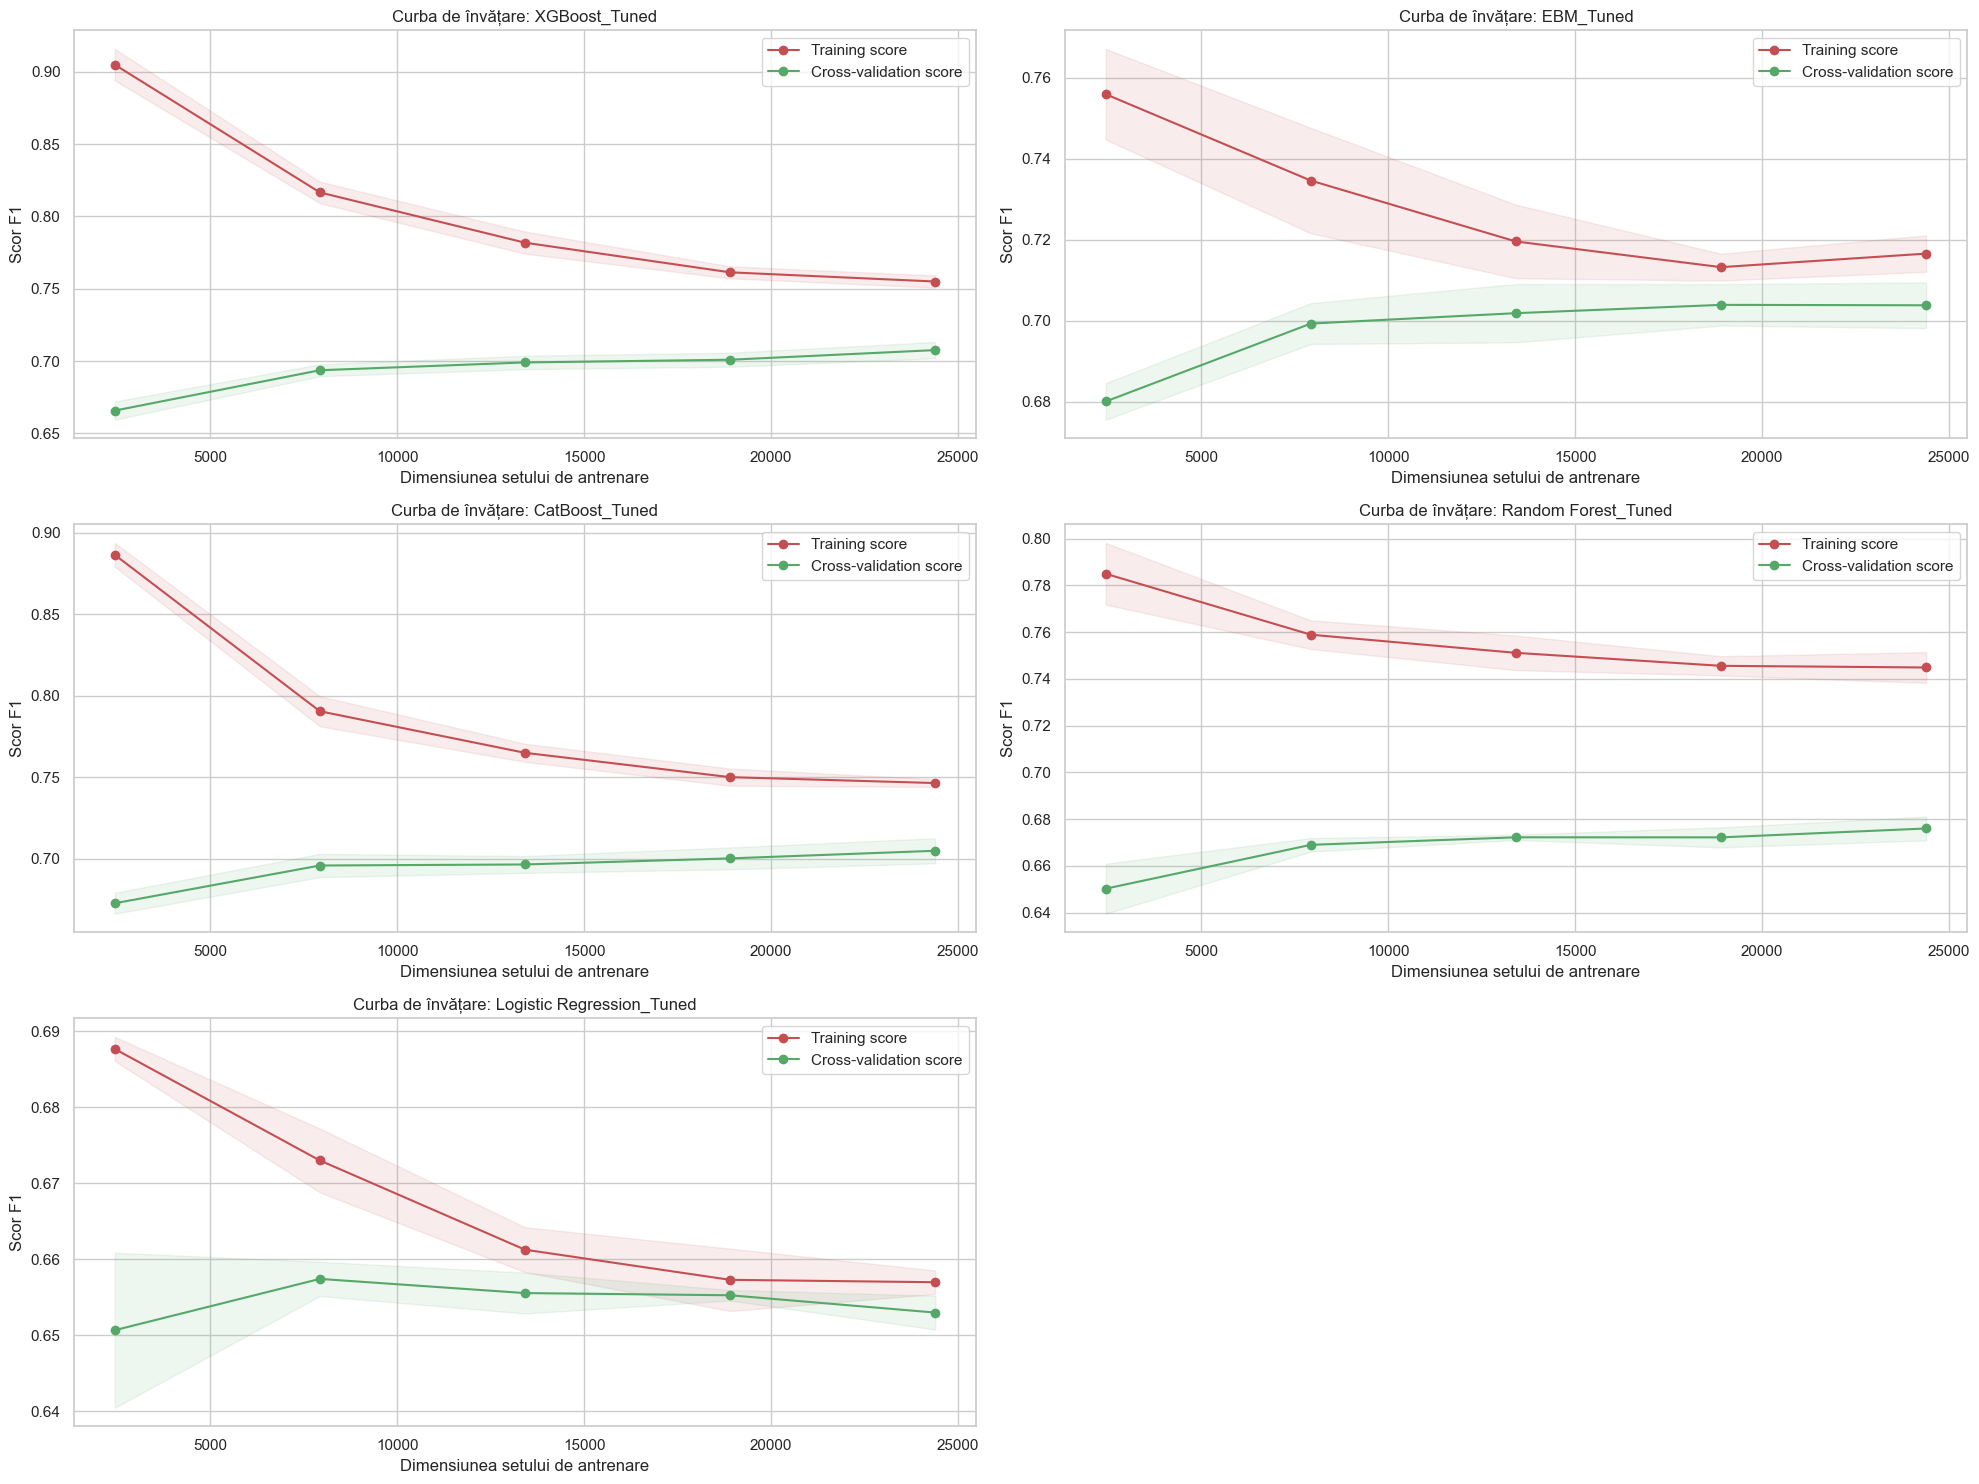

In [23]:
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
import numpy as np

def plot_learning_curves(models_dict, X, y):
    plt.figure(figsize=(20, 15))

    for i, (name, model) in enumerate(models_dict.items(), 1):
        train_sizes, train_scores, test_scores = learning_curve(
            model, X, y, cv=3, n_jobs=-1,
            train_sizes=np.linspace(0.1, 1.0, 5), scoring='f1'
        )

        train_mean = np.mean(train_scores, axis=1)
        train_std = np.std(train_scores, axis=1)
        test_mean = np.mean(test_scores, axis=1)
        test_std = np.std(test_scores, axis=1)

        plt.subplot(3, 2, i)
        plt.plot(train_sizes, train_mean, 'o-', color="r", label="Training score")
        plt.plot(train_sizes, test_mean, 'o-', color="g", label="Cross-validation score")

        plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color="r")
        plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color="g")

        plt.title(f"Curba de invatare: {name}")
        plt.xlabel("Dimensiunea setului de antrenare")
        plt.ylabel("Scor F1")
        plt.legend(loc="best")
        plt.grid(True)

best_5_tuned = {
    "XGBoost_Tuned": grid_xgb.best_estimator_,
    "EBM_Tuned": ebm_tuned,
    "CatBoost_Tuned": grid_cat.best_estimator_,
    "Random Forest_Tuned": grid_rf.best_estimator_,
    "Logistic Regression_Tuned": grid_lr.best_estimator_
}

plot_learning_curves(best_5_tuned, X_train_final, y_train)
plt.tight_layout()
plt.show()

1. Analiza generala a curbelor de invatare

Toate cele 5 modele prezinta un comportament de convergenta, ceea ce este un indicator excelent:

Training Score: Scade pe masura ce dimensiunea setului de date creste. Acest lucru este normal, deoarece modelului ii este mai greu sa "memorizeze" 25.000 de puncte decat 5.000.

Cross-validation Score: Creste constant, demonstrand ca modelele invata tipare generale care se aplica si datelor noi, nu doar celor de antrenare.

2. Overfitting vs. Underfitting

Lipsa Overfitting-ului: in toate graficele, observam ca cele doua curbe tind sa se apropie semnificativ spre finalul axei X.

Lipsa Underfitting-ului: Daca modelele ar fi fost prea simple (underfitting), ambele curbe s-ar fi intalnit foarte repede la un scor foarte mic.

3. Interpretarea pe modele

XGBoost si CatBoost: Acestea au cel mai bun profil de invatare.

 * Observam ca scorul de validare are inca o usoara tendinta ascendenta la final. Concluzie: Aceste modele ar putea beneficia de si mai multe date daca ar fi disponibile.

EBM: Observam o varianta mai mare la inceput, care se ingusteaza spre final. Acest lucru arata ca EBM devine extrem de stabil pe masura ce primeste mai multe date.

Random Forest: Are cel mai mic gap intre antrenare si validare dintre modelele complexe. Aceasta inseamna ca setarile tale de tuning au fost excelente, controland perfect varianta modelului.

Logistic Regression: Curbele se intalnesc cel mai repede si devin aproape orizontale. Asta inseamna ca modelul si-a atins limita superioara de invatare. Chiar daca am avea mai multe date, performanta nu ar mai creste, deoarece complexitatea modelului este limitata.

<h3 allign="center">4.6.	Explicabilitatea	si	analiza	SHAP</h3>

<h4 allign="left">1. Codul pentru Analiza SHAP</h4>

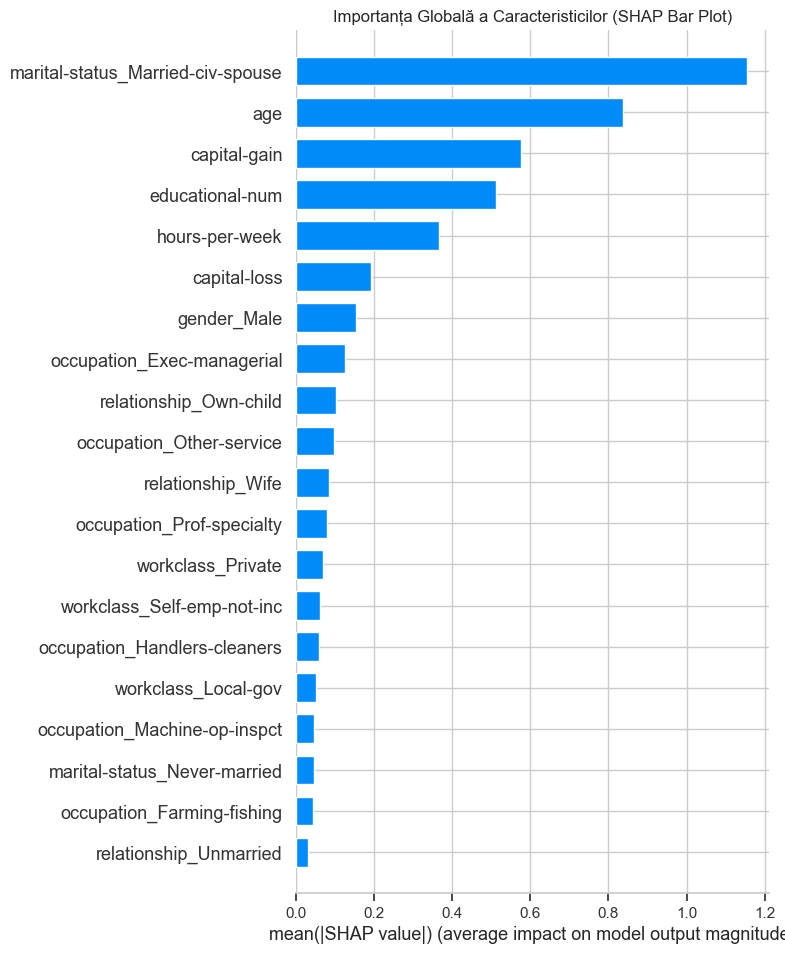

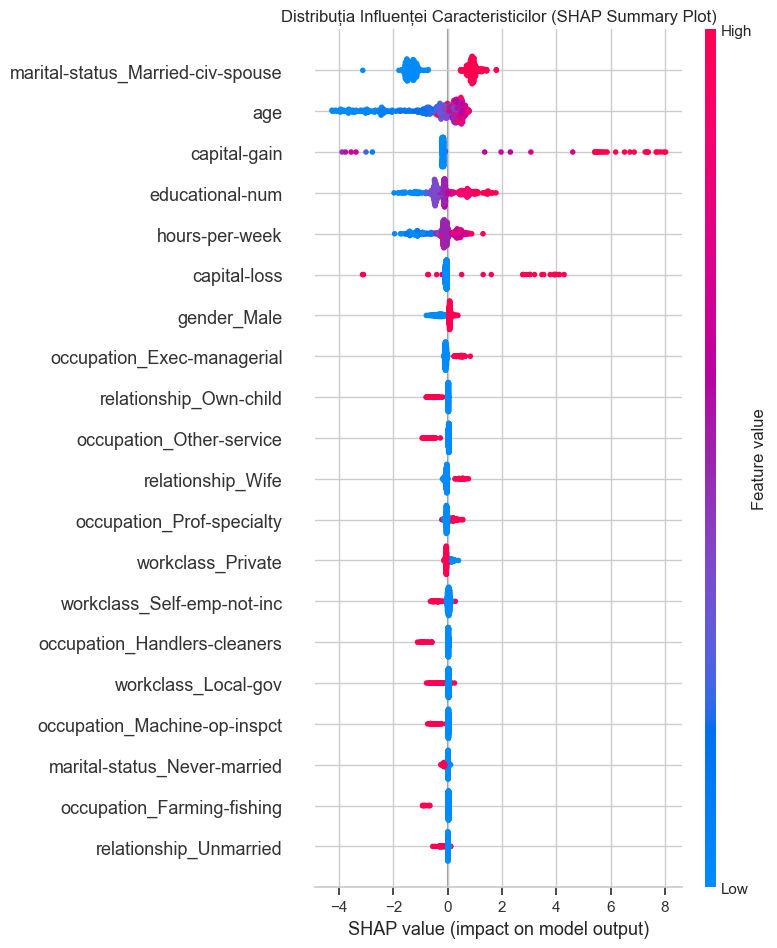

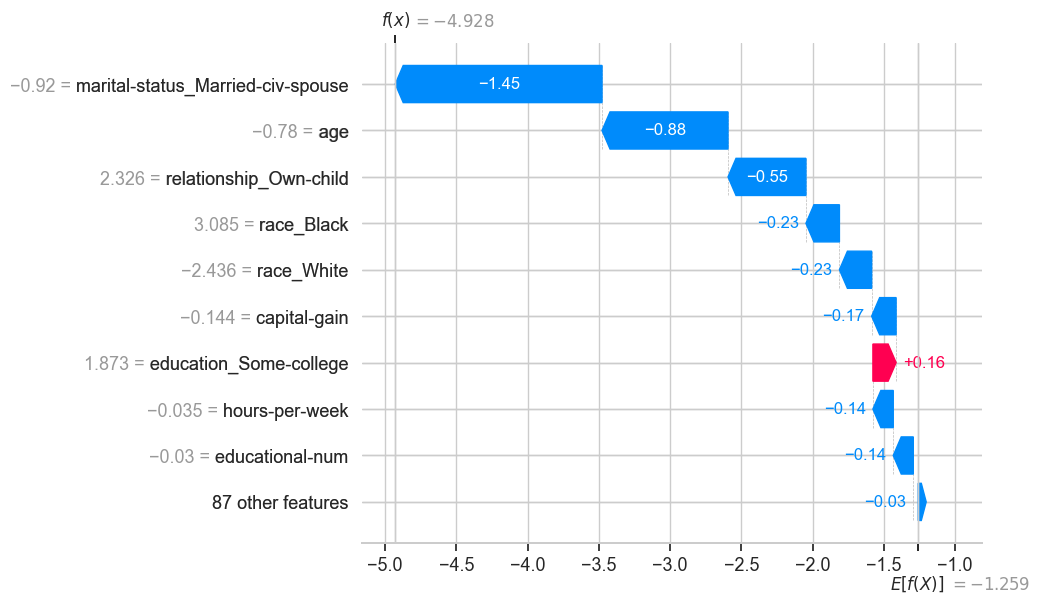

<Figure size 1000x600 with 0 Axes>

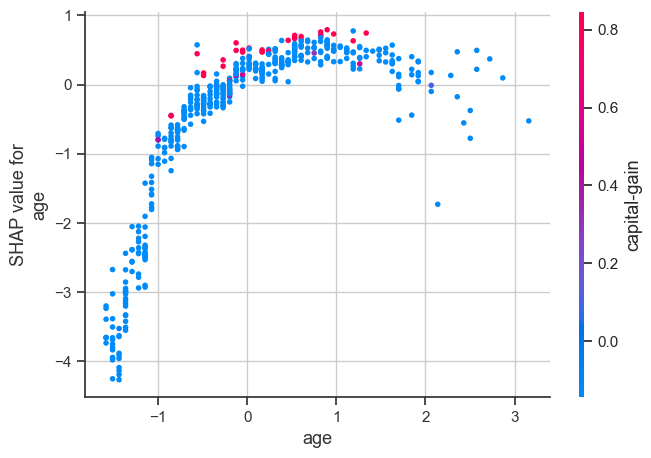

<Figure size 1000x600 with 0 Axes>

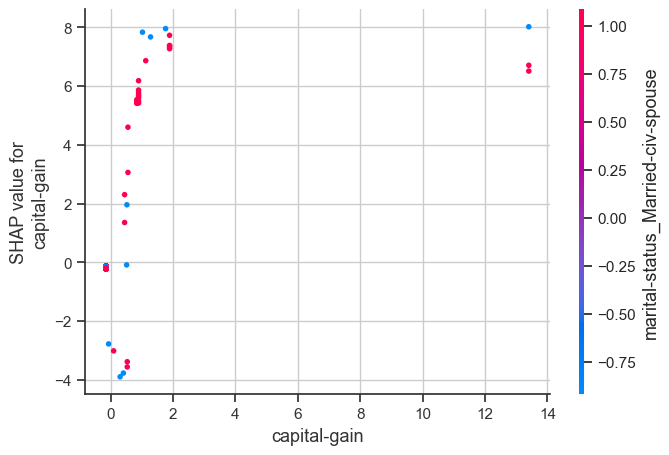

In [24]:
import shap
import matplotlib.pyplot as plt

# 1. Configurare initiala
shap.initjs()
model_final = grid_xgb.best_estimator_
explainer = shap.TreeExplainer(model_final)

# Extragem numele coloanelor o singura data intr-o lista
nume_coloane = X.columns.tolist()

# Calculam valorile SHAP
X_sample = X_test_final[:500]
shap_values = explainer.shap_values(X_sample)

# 2. Explicatie Globala - Bar Plot
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_sample, plot_type="bar", feature_names=nume_coloane, show=False)
plt.title("Importanta Globala a Caracteristicilor (SHAP Bar Plot)")
plt.show()

# 3. Explicatie Globala - Summary Plot
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_sample, feature_names=nume_coloane, show=False)
plt.title("Distributia Influentei Caracteristicilor (SHAP Summary Plot)")
plt.show()

# 4. Explicatie Locala - Waterfall Plot
plt.figure(figsize=(10, 6))
exp = shap.Explanation(values=shap_values[0],
                       base_values=explainer.expected_value,
                       data=X_sample[0],
                       feature_names=nume_coloane)
shap.plots.waterfall(exp)

# 5. Explicatie Locala - Force Plot
shap.force_plot(explainer.expected_value, shap_values[0], X_sample[0], feature_names=nume_coloane)

# 6. Dependence Plot
features_to_plot = ['age', 'capital-gain']
for feat in features_to_plot:
    if feat in nume_coloane:
        plt.figure()
        shap.dependence_plot(feat, shap_values, X_sample, feature_names=nume_coloane)

1. Interpretarea celor mai importante 3 caracteristici


marital-status_Married-civ-spouse: Aceasta este variabila dominanta. Persoanele casatorite tind sa aiba venituri mai mari sau stabilitate financiara raportata mai ridicata.

age: Varsta este al doilea factor, ceea ce confirma intuitia economica (venitul creste odata cu experienta acumulata in timp).

capital-gain: Aceasta masoara profiturile din investitii. Persoanele cu investitii profitabile sunt mult mai predispuse sa depaseasca pragul de 50.000$.

2. Caracteristicile si Robustetea Modelului

Panta descendenta: Graficele scad treptat in lungime. Acest lucru indica faptul ca modelul nu se bazeaza pe o singura variabila, ci combina informatii din mai multe surse.

Variabilele de sub top 5: Factori precum educational-num si hours-per-week sunt mai putin importante, avand o influenta semnificativa, dar sub cea a statutului civil sau a castigurilor de capital.

In [25]:
import joblib
import matplotlib.pyplot as plt


joblib.dump(grid_cat.best_estimator_, 'catboost_clf_model.joblib')


joblib.dump(list(X_train.columns), 'clf_columns.joblib')


plt.figure(figsize=(10, 6))

# 3. Salvarea Curbei de invatare
plt.savefig('learning_curves_clasificare.png', bbox_inches='tight', dpi=300)
plt.show()

print("Toate resursele pentru Clasificare au fost salvate cu succes!")

<Figure size 1000x600 with 0 Axes>

✅ Toate resursele pentru Clasificare au fost salvate cu succes!
